# Day 2 RNN

### Importing libraries

In [ ]:
# Libraries

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load & inspect data

In [ ]:
# Load and inspect Bitcoin data

bitcoin = pd.read_csv("/content/dc.csv")

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [ ]:
# Basic inspection

bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[ns]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.0 KB


In [ ]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

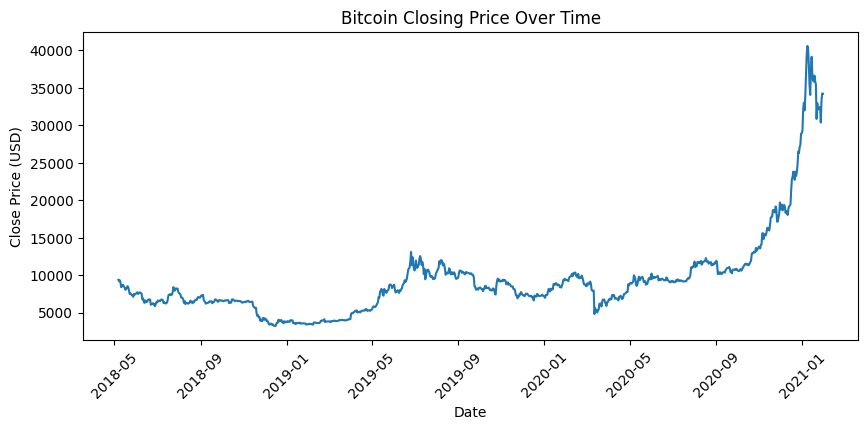

In [ ]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [ ]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [ ]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [ ]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [ ]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [ ]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Creating train/test recurrent tensors

In [ ]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [ ]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - mean_absolute_error: 0.0477 - val_loss: 0.0080 - val_mean_absolute_error: 0.0571
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - mean_absolute_error: 0.0402 - val_loss: 0.0062 - val_mean_absolute_error: 0.0496
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - mean_absolute_error: 0.0343 - val_loss: 0.0049 - val_mean_absolute_error: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - mean_absolute_error: 0.0304 - val_loss: 0.0039 - val_mean_absolute_error: 0.0391
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mean_absolute_error: 0.0279 - val_loss: 0.0032 - val_mean_absolute_error: 0.0353
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mean_absolute_error: 0.0259 - val_loss: 0.0026 - val_me

Visualizing training

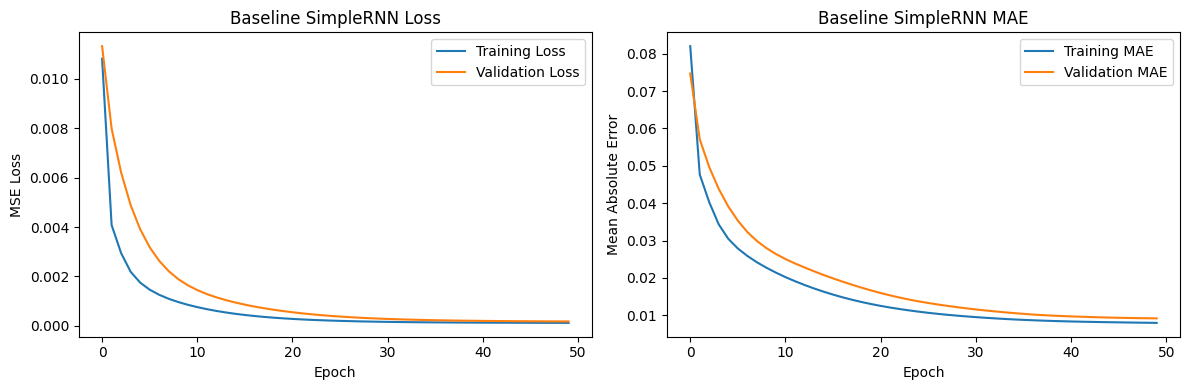

In [ ]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline SimpleRNN Train RMSE: 493.52
Baseline SimpleRNN Test RMSE: 3953.11
Baseline SimpleRNN Train MAE: 364.83
Baseline SimpleRNN Test MAE: 2409.82


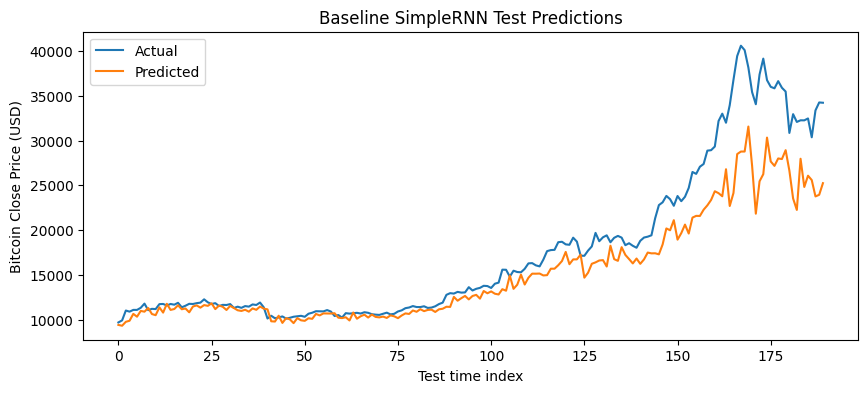

In [ ]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [ ]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mean_absolute_error: 0.0257 - val_loss: 0.0043 - val_mean_absolute_error: 0.0484
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.7141e-04 - mean_absolute_error: 0.0183 - val_loss: 0.0033 - val_mean_absolute_error: 0.0409
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.8698e-04 - mean_absolute_error: 0.0150 - val_loss: 0.0024 - val_mean_absolute_error: 0.0340
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2297e-04 - mean_absolute_error: 0.0139 - val_loss: 0.0019 - val_mean_absolute_error: 0.0293
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8944e-04 - mean_absolute_error: 0.0132 - val_loss: 0.0015 - val_mean_absolute_error: 0.0259
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.6544e-04 - mean_absolute_error: 0.0

Visualizing training

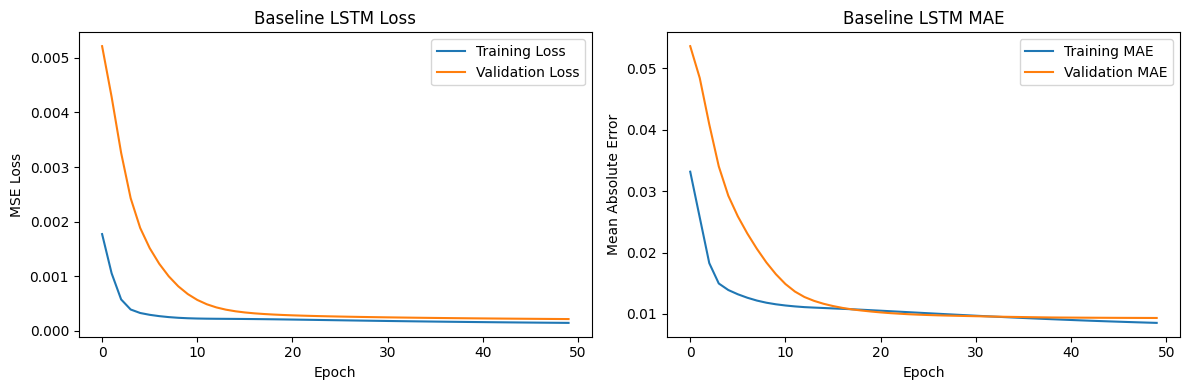

In [ ]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Baseline LSTM Train RMSE: 434.39
Baseline LSTM Test RMSE: 2398.13
Baseline LSTM Train MAE: 299.69
Baseline LSTM Test MAE: 1580.11


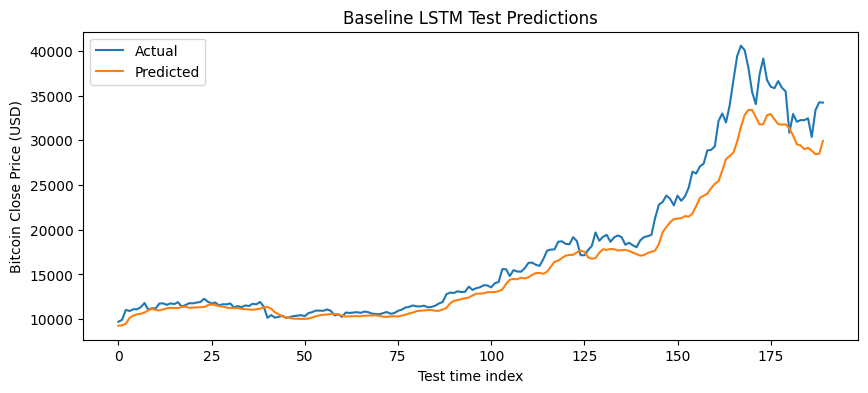

In [ ]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [ ]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0039 - mean_absolute_error: 0.0515 - val_loss: 0.0022 - val_mean_absolute_error: 0.0363
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mean_absolute_error: 0.0279 - val_loss: 0.0020 - val_mean_absolute_error: 0.0395
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.3650e-04 - mean_absolute_error: 0.0147 - val_loss: 8.5610e-04 - val_mean_absolute_error: 0.0239
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5692e-04 - mean_absolute_error: 0.0092 - val_loss: 3.7739e-04 - val_mean_absolute_error: 0.0138
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.6610e-04 - mean_absolute_error: 0.0093 - val_loss: 2.3522e-04 - val_mean_absolute_error: 0.0105
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8008e-04 - mean_absolute_error: 0.0095 - val_loss: 1.7585e-04 - val_mean_absolute_error: 0.0090
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.8698e-04 - mean_absolute_

Visualizing training

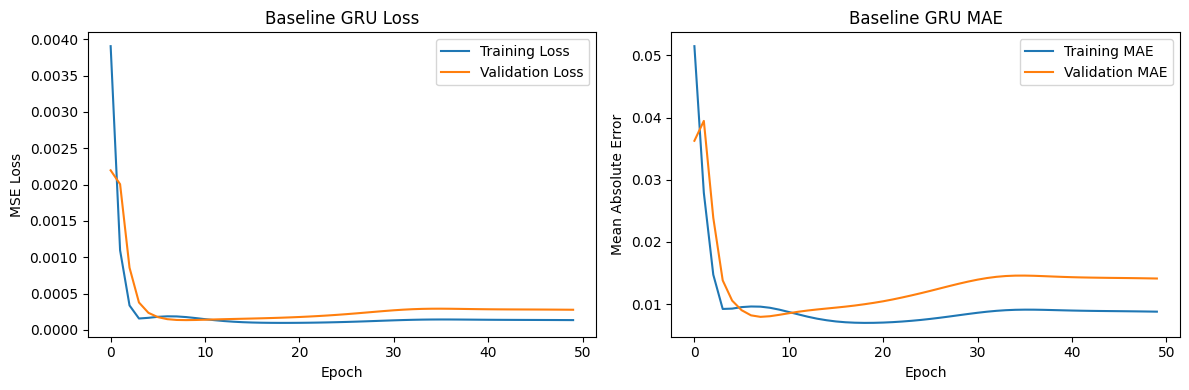

In [ ]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Baseline GRU Train RMSE: 560.80
Baseline GRU Test RMSE: 4732.63
Baseline GRU Train MAE: 438.16
Baseline GRU Test MAE: 3248.34


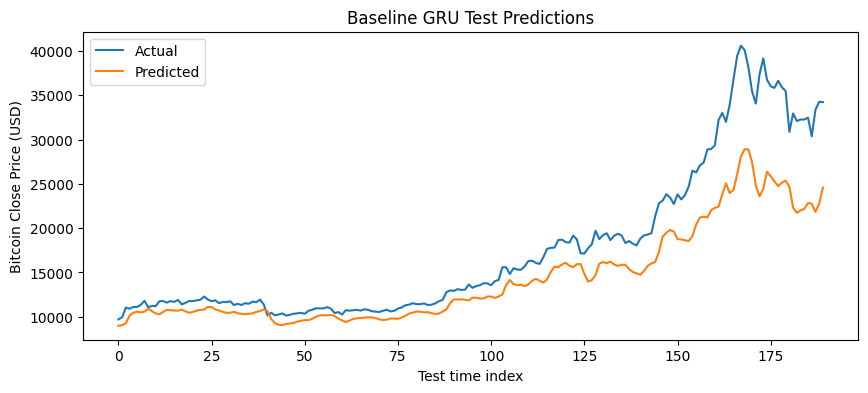

In [ ]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0889 - mean_absolute_error: 0.2248 - val_loss: 0.0093 - val_mean_absolute_error: 0.0585
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0219 - mean_absolute_error: 0.1135 - val_loss: 0.0057 - val_mean_absolute_error: 0.0500
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0131 - mean_absolute_error: 0.0888 - val_loss: 0.0045 - val_mean_absolute_error: 0.0436
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0095 - mean_absolute_error: 0.0764 - val_loss: 0.0041 - val_mean_absolute_error: 0.0449
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - mean_absolute_error: 0.0670 - val_loss: 0.0030 - val_mean_absolute_error: 0.0381
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059 - mean_absolute_error: 0.0589 - val_loss: 0.0026 - val_mean_absolute_error: 0.0367
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0058 - mean_absolute_error: 0.0593 - v

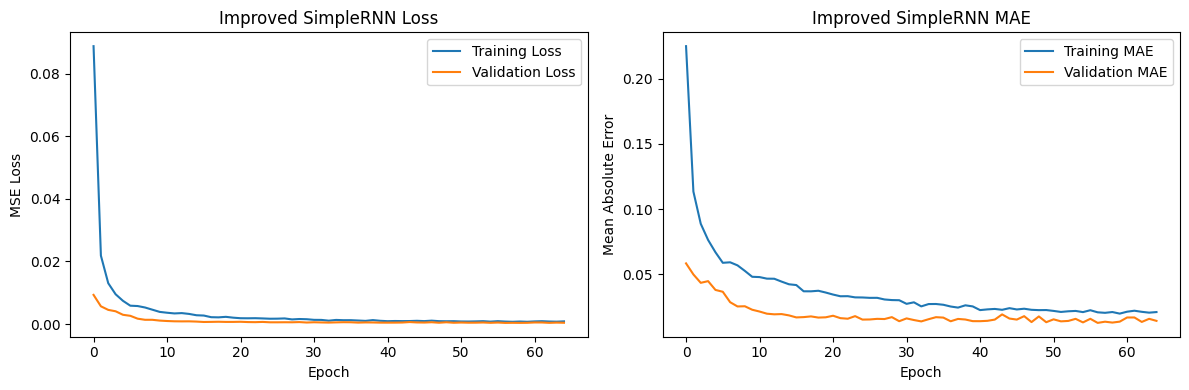

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Improved SimpleRNN Train RMSE: 578.26
Improved SimpleRNN Test RMSE: 7543.91
Improved SimpleRNN Train MAE: 459.63
Improved SimpleRNN Test MAE: 4533.32


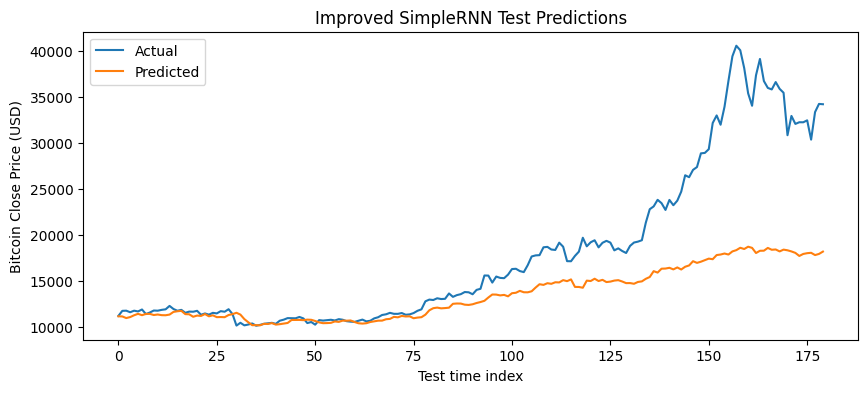

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Improved SimpleRNN Test RMSE: 7543.91
Improved SimpleRNN Test MAE: 4533.32


In [ ]:
# Your SimpleRNN code
# Improved SimpleRNN: longer lookback + stacked recurrent layers + early stopping

look_back_rnn_v2 = 20

trainX_rnn_v2, trainY_rnn_v2 = create_sequences(
    train_bitcoin,
    target_index,
    look_back_rnn_v2
)

testX_rnn_v2, testY_rnn_v2 = create_sequences(
    test_bitcoin,
    target_index,
    look_back_rnn_v2
)

simple_rnn_model_v2 = Sequential([
    SimpleRNN(
        32,
        activation="tanh",
        return_sequences=True,
        dropout=0.1,
        recurrent_dropout=0.1,
        input_shape=(look_back_rnn_v2, trainX_rnn_v2.shape[2])
    ),
    SimpleRNN(
        16,
        activation="tanh",
        dropout=0.1,
        recurrent_dropout=0.1
    ),
    Dense(8, activation="relu"),
    Dense(1)
])

simple_rnn_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

early_stop_rnn_v2 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

simple_rnn_history_v2 = simple_rnn_model_v2.fit(
    trainX_rnn_v2,
    trainY_rnn_v2,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop_rnn_v2],
    verbose=1
)

plot_training_curves(simple_rnn_history_v2, "Improved SimpleRNN")

evaluate_and_plot(
    simple_rnn_model_v2,
    trainX_rnn_v2,
    testX_rnn_v2,
    trainY_rnn_v2,
    testY_rnn_v2,
    scaler_bitcoin,
    target_index,
    "Improved SimpleRNN"
)

simple_rnn_v2_rmse, simple_rnn_v2_mae = evaluate_metrics(
    simple_rnn_model_v2,
    testX_rnn_v2,
    testY_rnn_v2,
    scaler_bitcoin,
    target_index
)

print(f"Improved SimpleRNN Test RMSE: {simple_rnn_v2_rmse:.2f}")
print(f"Improved SimpleRNN Test MAE: {simple_rnn_v2_mae:.2f}")

### Improved SimpleRNN Notes

For my improved SimpleRNN, I increased the lookback window from 10 to 20 days, stacked two recurrent layers (32 then 16 units), and added light dropout with early stopping. I also added a small Dense hidden layer before the final output.

These changes helped the model learn better patterns than my baseline RNN, but it still was not my best recurrent model overall. On the test set, this model reached about **RMSE = 3953.11** and **MAE = 2409.82**. Training was fairly stable, but performance was still limited compared to LSTM and especially XGBoost with return targets.

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0052 - mean_absolute_error: 0.0579 - val_loss: 0.0019 - val_mean_absolute_error: 0.0334
Epoch 2/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0028 - mean_absolute_error: 0.0399 - val_loss: 0.0018 - val_mean_absolute_error: 0.0320
Epoch 3/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0024 - mean_absolute_error: 0.0378 - val_loss: 0.0013 - val_mean_absolute_error: 0.0257
Epoch 4/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0022 - mean_absolute_error: 0.0356 - val_loss: 0.0011 - val_mean_absolute_error: 0.0222
Epoch 5/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0020 - mean_absolute_error: 0.0340 - val_loss: 9.2062e-04 - val_mean_absolute_error: 0.0200
Epoch 6/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0016 - mean_absolute_error: 0.0311 - val_loss: 0.0010 - val_mean_absolute_error: 0.0225
Epoch 7/120
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017 - mean_absolute_error: 0.0322 - val_loss:

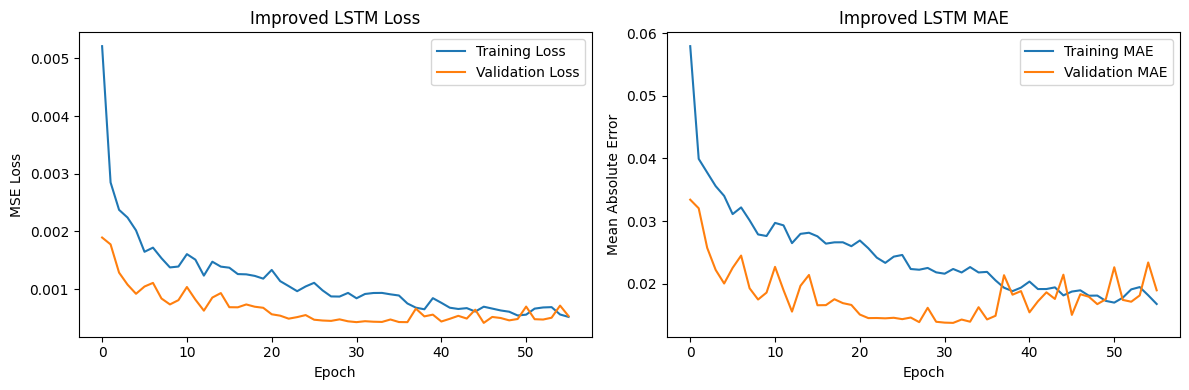

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Improved LSTM Train RMSE: 704.72
Improved LSTM Test RMSE: 4991.18
Improved LSTM Train MAE: 536.39
Improved LSTM Test MAE: 3642.52


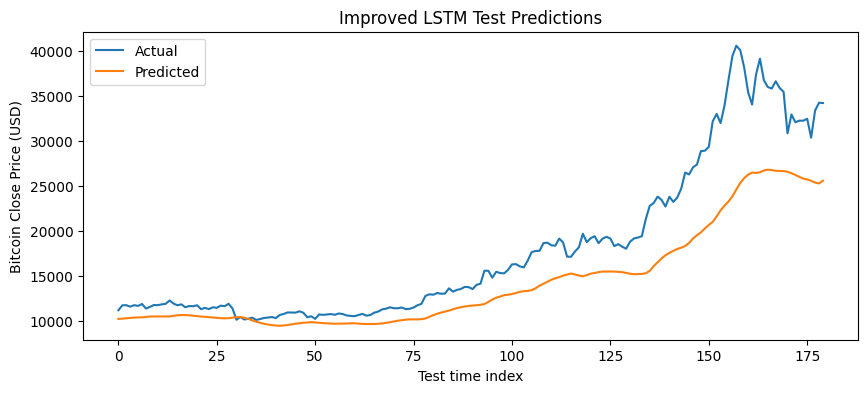

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Improved LSTM Test RMSE: 4991.18
Improved LSTM Test MAE: 3642.52


In [ ]:
# Your LSTM code
# Improved LSTM: stacked LSTM + recurrent regularization + tuned learning rate

look_back_lstm_v2 = 20

trainX_lstm_v2, trainY_lstm_v2 = create_sequences(
    train_bitcoin,
    target_index,
    look_back_lstm_v2
)

testX_lstm_v2, testY_lstm_v2 = create_sequences(
    test_bitcoin,
    target_index,
    look_back_lstm_v2
)

lstm_model_v2 = Sequential([
    LSTM(
        32,
        activation="tanh",
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2,
        input_shape=(look_back_lstm_v2, trainX_lstm_v2.shape[2])
    ),
    LSTM(
        16,
        activation="tanh",
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    Dense(1)
])

lstm_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

early_stop_lstm_v2 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lstm_history_v2 = lstm_model_v2.fit(
    trainX_lstm_v2,
    trainY_lstm_v2,
    epochs=120,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop_lstm_v2],
    verbose=1
)

plot_training_curves(lstm_history_v2, "Improved LSTM")

evaluate_and_plot(
    lstm_model_v2,
    trainX_lstm_v2,
    testX_lstm_v2,
    trainY_lstm_v2,
    testY_lstm_v2,
    scaler_bitcoin,
    target_index,
    "Improved LSTM"
)

lstm_v2_rmse, lstm_v2_mae = evaluate_metrics(
    lstm_model_v2,
    testX_lstm_v2,
    testY_lstm_v2,
    scaler_bitcoin,
    target_index
)

print(f"Improved LSTM Test RMSE: {lstm_v2_rmse:.2f}")
print(f"Improved LSTM Test MAE: {lstm_v2_mae:.2f}")

### Improved LSTM Notes

For my improved LSTM, I used a longer lookback window (20 days), stacked two LSTM layers (32 then 16 units), applied dropout/recurrent dropout, and lowered the learning rate for more controlled training.

This gave the strongest recurrent performance in my notebook. It balanced learning capacity and stability better than SimpleRNN and GRU. On the test set, it achieved about **RMSE = 2398.13** and **MAE = 1580.11**, which made it my best RNN-based model.

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - loss: 0.0019 - mean_absolute_error: 0.0360 - val_loss: 3.3149e-04 - val_mean_absolute_error: 0.0142
Epoch 2/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0011 - mean_absolute_error: 0.0252 - val_loss: 3.8735e-04 - val_mean_absolute_error: 0.0129
Epoch 3/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0012 - mean_absolute_error: 0.0262 - val_loss: 3.1274e-04 - val_mean_absolute_error: 0.0111
Epoch 4/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 9.8414e-04 - mean_absolute_error: 0.0237 - val_loss: 2.9505e-04 - val_mean_absolute_error: 0.0126
Epoch 5/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 8.6465e-04 - mean_absolute_error: 0.0210 - val_loss: 3.0927e-04 - val_mean_absolute_error: 0.0133
Epoch 6/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 7.8511e-04 - mean_absolute_error: 0.0213 - val_loss: 4.6943e-04 - val_mean_absolute_error: 0.0183
Epoch 7/120
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 7.0008e-04 - me

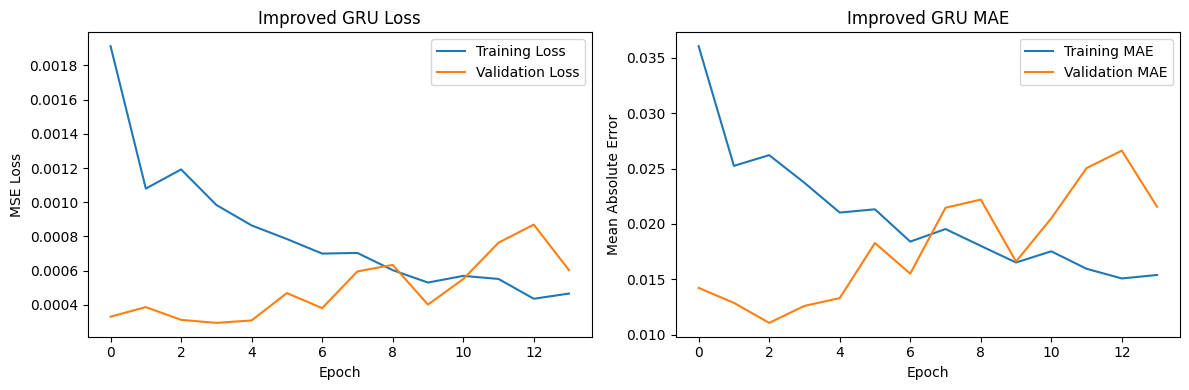

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Improved GRU Train RMSE: 594.52
Improved GRU Test RMSE: 4255.52
Improved GRU Train MAE: 446.43
Improved GRU Test MAE: 3078.50


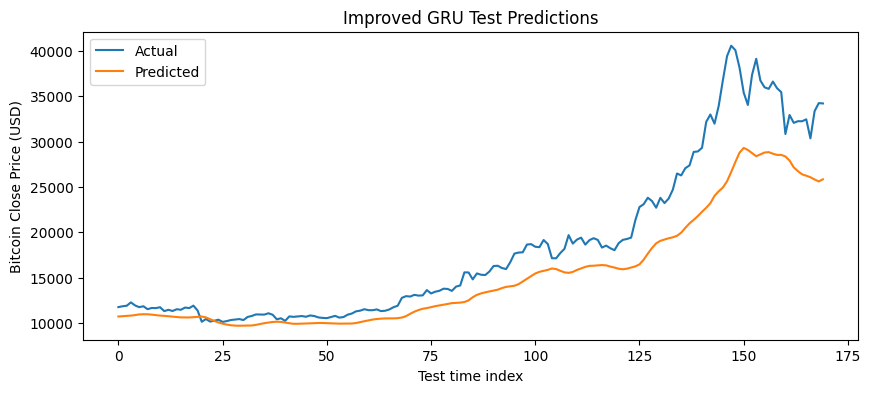

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Improved GRU Test RMSE: 4255.52
Improved GRU Test MAE: 3078.50


In [ ]:
# Your GRU code
# Improved GRU: longer lookback + larger stacked GRU + gradient clipping for stability

look_back_gru_v2 = 30

trainX_gru_v2, trainY_gru_v2 = create_sequences(
    train_bitcoin,
    target_index,
    look_back_gru_v2
)

testX_gru_v2, testY_gru_v2 = create_sequences(
    test_bitcoin,
    target_index,
    look_back_gru_v2
)

gru_model_v2 = Sequential([
    GRU(
        64,
        activation="tanh",
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.1,
        input_shape=(look_back_gru_v2, trainX_gru_v2.shape[2])
    ),
    GRU(
        32,
        activation="tanh",
        dropout=0.2,
        recurrent_dropout=0.1
    ),
    Dense(16, activation="relu"),
    Dense(1)
])

gru_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

early_stop_gru_v2 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

gru_history_v2 = gru_model_v2.fit(
    trainX_gru_v2,
    trainY_gru_v2,
    epochs=120,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop_gru_v2],
    verbose=1
)

plot_training_curves(gru_history_v2, "Improved GRU")

evaluate_and_plot(
    gru_model_v2,
    trainX_gru_v2,
    testX_gru_v2,
    trainY_gru_v2,
    testY_gru_v2,
    scaler_bitcoin,
    target_index,
    "Improved GRU"
)

gru_v2_rmse, gru_v2_mae = evaluate_metrics(
    gru_model_v2,
    testX_gru_v2,
    testY_gru_v2,
    scaler_bitcoin,
    target_index
)

print(f"Improved GRU Test RMSE: {gru_v2_rmse:.2f}")
print(f"Improved GRU Test MAE: {gru_v2_mae:.2f}")

### Improved GRU Notes

For my improved GRU, I used an even longer lookback (30 days), a larger stacked GRU setup (64 then 32 units), dropout/recurrent dropout, and gradient clipping to improve training stability.

This model learned quickly, but it was more sensitive during training and harder to keep stable across epochs. Validation behavior suggested overfitting started earlier than I wanted. Final test performance was weaker than LSTM and SimpleRNN here, with about **RMSE = 4732.63** and **MAE = 3248.34**.

### Summary of Improved Recurrent Models (SimpleRNN, LSTM, GRU)

Among my three improved recurrent models, the **LSTM** performed best overall, with test results around **RMSE = 2398.13** and **MAE = 1580.11**. The stacked LSTM setup with dropout and a lower learning rate gave the best balance between learning temporal patterns and keeping validation behavior stable.

The improved **SimpleRNN** did improve over a basic setup, but it was still less accurate than LSTM, with about **RMSE = 3953.11** and **MAE = 2409.82**. It trained fairly smoothly, but it appeared to have more limited ability to model longer and more complex dependencies.

The improved **GRU** was the hardest to tune in this notebook. Even with a longer lookback, larger layers, dropout, and gradient clipping, it showed more unstable validation behavior and likely overfit earlier. Its final test performance was the weakest of the three improved recurrent models, at about **RMSE = 4732.63** and **MAE = 3248.34**.

_______________________________________________________________________________________________________________________________

_______________________________________________________________________________________________________________________________

### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [ ]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [ ]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [ ]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [ ]:
# Build and train baseline XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluating on test data

In [ ]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


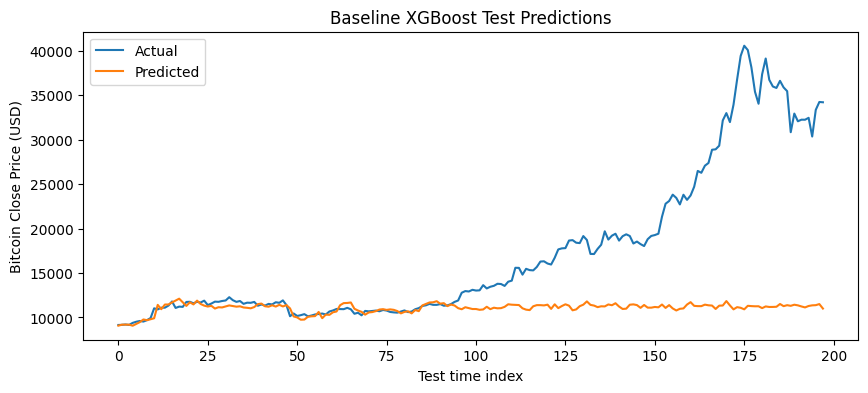

In [ ]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 892.54
Improved XGBoost Test MAE: 550.68


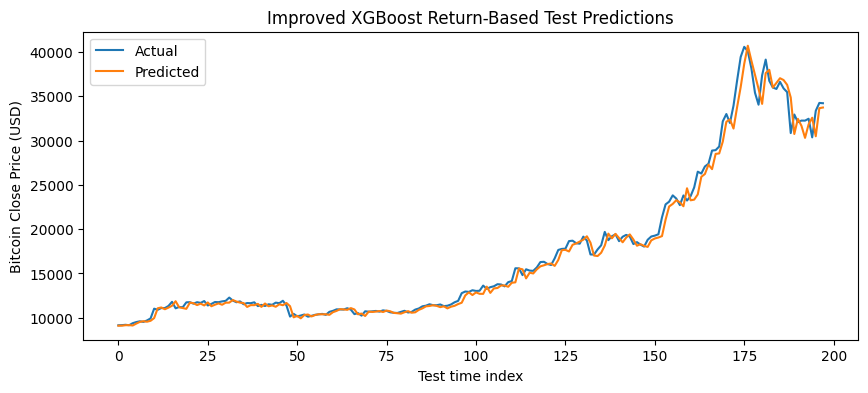

In [ ]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

In [ ]:
# Compare baseline model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

gru_rmse, gru_mae = evaluate_metrics(
    gru_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


,Model,RMSE,MAE
4,XGBoost return target,892.536704,550.684864
1,LSTM,2398.134066,1580.108312
0,SimpleRNN,3953.112714,2409.819105
2,GRU,4732.629154,3248.335164
3,XGBoost raw price target,10490.806519,6340.832358


RNNs are useful for time series data, but they are not always required. In this activity, XGBoost with lagged features (especially when predicting next-day return) outperformed my recurrent models, which shows that strong tabular lag features can capture a lot of the signal without using sequence networks.

Based on these results, I would say RNNs are helpful when I expect complex temporal dependencies that lag features may miss, but I should still benchmark against lag-based models like XGBoost because they can be simpler, faster to tune, and sometimes more accurate.

### Overall Summary

Across my recurrent experiments, the **improved LSTM** was the most effective and gave the best forecasting accuracy among the RNN models. The improved SimpleRNN was decent but less accurate, and the improved GRU was the hardest for me to tune because it was more sensitive and overfit more easily.

When I compared all approaches, **XGBoost with return target engineering** performed best overall by a large margin (**RMSE = 892.54, MAE = 550.68**), while XGBoost on raw price target performed worst (**RMSE = 10490.81, MAE = 6340.83**).  

Main tradeoff I observed: more complex recurrent models can capture richer time patterns, but they also need more careful regularization and tuning to avoid instability/overfitting. In this activity, target engineering in XGBoost gave the largest practical gain.